In [243]:

import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import time


rcParams.update({'font.size': 14})

from py21cmemu import Emulator



### Get the redshift values, xHI values and redshift at which 1d power spectrum values are avilable

In [244]:
# Load the 1D summaries test set
test_1d_path = '/home/leon/Documents/codes/21cmEMU/docs/tutorials/test_database.h5' 

# only need the 1D power spectrum and xHI values

with h5py.File(test_1d_path, 'r') as f:
    print("Test set keys:", list(f.keys())) # test set keys

    # Input parameters (11 astrophysical params)
    test_params = np.array(f['input_params'])

    # 1D summaries
    test_xHI = np.array(f['xHI'])
    # test_Tb = np.array(f['Tb'])
    # test_Ts = np.array(f['Ts'])
    # test_tau = np.array(f['tau'])
    test_PS_1D = np.array(f['PS_1D_seeds']) # shape is (Nparams, Nseeds, Nz, Nk)
    PS_redshifts = np.array(f['PS_redshifts'])
    k = np.array(f["k"])
    # UVLFs: (N, 7 z-bins, 60 magnitudes)
    # test_LFs_raw = np.array(f['UVLFs'])

    # Axes
    redshifts = np.array(f['redshifts'])
    # M_UV_all = np.array(f['M_UV'])
    # LF_zs = np.array(f['UVLF_redshifts'])
    limits = np.array(f["limits"])
    ap = np.array(f["astro_param_keys"])

# Filter valid samples (no NaN inputs)
valid_mask = ~np.isnan(test_params.mean(axis=1))
print(f"Valid samples: {valid_mask.sum()} / {len(test_params)}")

test_params = test_params[valid_mask]
test_xHI = test_xHI[valid_mask]
# test_Tb = test_Tb[valid_mask]
# test_Ts = test_Ts[valid_mask]
# test_tau = test_tau[valid_mask]
# test_LFs_raw = test_LFs_raw[valid_mask]
test_PS_1D = test_PS_1D[valid_mask]
# m = np.logical_and(M_UV_all < -10, M_UV_all > -20)
# Trim UVLFs to M_UV in [-20, -10]
# M_UV = M_UV_all[m]  # Crop to 30 magnitudes
# test_LFs = test_LFs_raw[:, :, m]  # (N, 7, 30)

print("\nData shapes:")
print(f"  Params: {test_params.shape}")
print(f"  xHI: {test_xHI.shape}")
# print(f"  Tb: {test_Tb.shape}")
# print(f"  Ts: {test_Ts.shape}")
# print(f"  tau: {test_tau.shape}")
# print(f"  UVLFs: {test_LFs.shape}")
print(f"  Redshifts: {redshifts.shape}")

Test set keys: ['M_UV', 'PS_1D_seeds', 'PS_redshifts', 'Tb', 'Ts', 'UVLF_redshifts', 'UVLFs', 'astro_param_keys', 'astro_param_labels', 'input_params', 'k', 'limits', 'redshifts', 'tau', 'xHI']
Valid samples: 80 / 80

Data shapes:
  Params: (80, 11)
  xHI: (80, 93)
  Redshifts: (93,)


### Test Emulation of 1d ps

In [272]:
# choose the redshift value to get the 1D power spectrum
redshift_value = 8.01 
index_z = np.where(np.round(PS_redshifts, 2) == redshift_value)[0][0] # index of the redshift value in the PS_redshifts array

In [273]:
# fiducial parameters for the emulator
log_f_star10 = -1.2
alpha_star = 0.5
t_star = 0.55
log_f_esc10 = -1.3
alpha_esc = 0
log_f_star7_mini = -2.5
log_f_esc7_mini = -1.5
log_l_x = 40.0
log_l_x_mini = 41.5
nu_x_thresh = 500
sigma_8 = 0.8118


astro_params = {"F_STAR10": log_f_star10, 
          'ALPHA_STAR': alpha_star,
          't_STAR': t_star,
          'F_ESC10': log_f_esc10,
          'ALPHA_ESC': alpha_esc,
          'F_STAR7_MINI': log_f_star7_mini,
          'F_ESC7_MINI': log_f_esc7_mini,
          'L_X': log_l_x,
          'L_X_MINI': log_l_x_mini,
          'NU_X_THRESH': nu_x_thresh,
          'SIGMA_8': sigma_8
         }

In [274]:
print("Astrophysical parameters for the emulator")

Astrophysical parameters for the emulator


In [271]:
# # calling the emulator with the default settings
# emu = Emulator(emulator="mcg", emulate_2d_ps=False)
# params, outputs, errors = emu.predict(params)

In [275]:
# x_HI = outputs["xHI"].value
# ps_1d = outputs ["PS"].value

In [276]:
# plt.plot(redshifts, x_HI)

In [277]:
# ps_1d_at_z = (ps_1d[index_z])  # shape is (Nk,) power spectrum at the chosen redshift in units of mK^2

In [279]:
# plt.figure(figsize=(8, 6))
# plt.plot(k, ps_1d_at_z, label=f'21cmEMU Prediction at z={redshift_value}', color='blue')
# plt.xscale('log')
# plt.xlabel(r'$k$ [Mpc$^{-1}$]')
# plt.ylabel(r'$\Delta^2(k)$ [mK$^2$]')

In [ ]:
def simu_1d_ps(theta, redshift_value):
    """
    Simulate the 1D power spectrum using the 21cmEMU emulator for given parameters and redshift.

    Parameters:
    theta (array): Array containing the astrophysical parameters.
    redshift_value (float): The redshift value at which to compute the power spectrum.

    Returns:
    tuple: A tuple containing the 1D power spectrum and the corresponding k values.
    """
    # Initialize the emulator
    emu = Emulator(emulator="mcg", emulate_2d_ps=False)
    
    # Predict outputs using the emulator
    _params, outputs, errors = emu.predict(theta)
    
    # Extract the 1D power spectrum and redshifts
    ps_1d = outputs["PS"].value
    PS_redshifts = np.array(outputs["PS_redshifts"].value)
    
    # Find the index of the specified redshift
    index_z = np.where(np.round(PS_redshifts, 2) == redshift_value)[0][0]
    
    # Get the 1D power spectrum at the specified redshift
    ps_1d_at_z = ps_1d[index_z]
    
    return ps_1d_at_z 

In [301]:
ps_1_d = simu_1d_ps(astro_params, redshift_value = 8.01) 

sigma_noise = 0.05 * ps_1_d # 5% noise level
np.random.seed(20)  # for reproducibility
ps_noisy = ps_1_d + np.random.normal(0, sigma_noise, size=ps_1_d.shape) # add noise to the power spectrum   

Text(0, 0.5, '$\\Delta^2(k)$ [mK$^2$]')

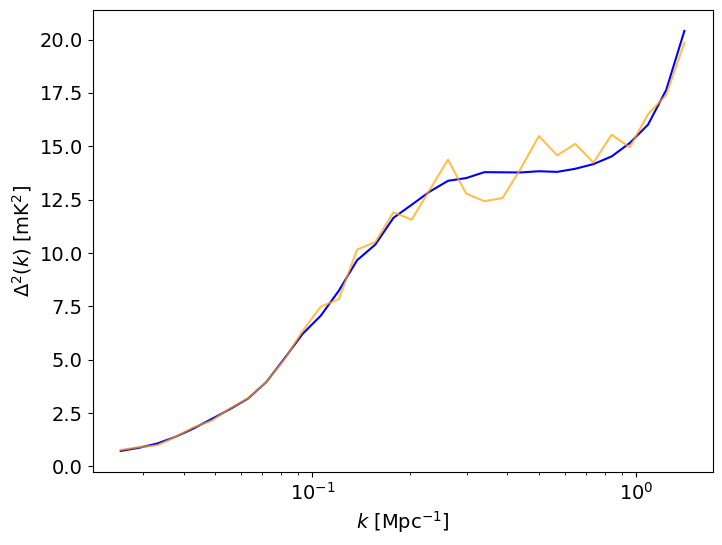

In [300]:
plt.figure(figsize=(8, 6))
plt.plot(k, ps_1_d, label=f'21cmEMU Prediction at z={redshift_value}', color='blue')
plt.plot(k, ps_noisy, label=f'Noisy Power Spectrum at z={redshift_value}', color='orange', alpha=0.7)
plt.xscale('log')
plt.xlabel(r'$k$ [Mpc$^{-1}$]')
plt.ylabel(r'$\Delta^2(k)$ [mK$^2$]')

In [304]:
np.save('/home/leon/Documents/codes/sbi_21cm_ps/data/k_values.npy', k)